## Analysing performance of different uncertainty quantifiers across different correctness criteria

#### 1. Importing relevant libraries

In [1]:
import json
from math import exp
import numpy as np
import math
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

#### 2. Shared plot styling functions for readability

In [1]:
UNCERTAINTY_LABELS = {
    "entropy_scores": "Ent.",
    "semantic_entropy_scores": "Sem. entropy",
    "semantic_confidence_scores": "Sem. conf.",
    "prob_sequence_scores": "P(seq.)",
    "prob_avg_token_scores": "N.P(seq.)",
    "prob_true_scores": "P(true)",
    "verbalised_confidence_scores": "Verb. conf.",
}

def format_uncertainty_label(name):
    return UNCERTAINTY_LABELS[name]

def format_correctness_label(name):
    if name == "manual":
        return "Human labels"
    if name == "exact_match_correctness":
        return "Exact match"
    if name == "llm_as_judge_correctness_os":
        return "LLM judge (Llama 8B)"
    if name == "llm_as_judge_correctness_api":
        return "LLM judge (GPT)"
    if name == "llm_as_judge_correctness":
        return "LLM judge"
    if name.startswith("token_f1_"):
        return f"Token F1 (τ={name.removeprefix('token_f1_')})"
    if name.startswith("bleu_"):
        return f"BLEU (τ={name.removeprefix('bleu_')})"
    if name.startswith("rouge_l_"):
        return f"ROUGE-L (τ={name.removeprefix('rouge_l_')})"
    if name.startswith("embedding_similarity_"):
        return f"Emb. sim. (τ={name.removeprefix('embedding_similarity_')})"
    if name.startswith("bert_score_"):
        return f"BERTScore (τ={name.removeprefix('bert_score_')})"
    return name.replace("_", " ").title()

In [ ]:
sns.set_theme(style="whitegrid", context="talk", palette="tab10")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
})


def wrap_label(text, max_len=24, type_label=None):
    """Wrap long axis/legend labels onto multiple lines."""
    if type_label == "correctness":
        text = format_correctness_label(str(text))
    elif type_label == "uncertainty":
        text = format_uncertainty_label(str(text))
    else:
        text = text.replace("_", " ")
    
    if len(text) <= max_len:
        return text
    words = text.split()
    lines, current = [], ""
    for word in words:
        candidate = f"{current} {word}".strip()
        if len(candidate) <= max_len:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return "\n".join(lines)


def style_axes(ax=None, y_grid=True):
    ax = ax or plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if y_grid:
        ax.grid(True, axis="y", alpha=0.35, linestyle="--", linewidth=0.8)
    ax.tick_params(axis="both", which="major", labelsize=10)


def legend_outside(ax=None, title=None, ncol=None, fontsize=9):
    ax = ax or plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    if ncol is None:
        ncol = 2 if len(labels) > 8 else 1
    ax.legend(
        handles,
        labels,
        title=title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        framealpha=0.95,
        fontsize=fontsize,
        title_fontsize=fontsize + 1,
        ncol=ncol,
        borderaxespad=0,
    )


def style_violinplot(parts, facecolor="#4C72B0", edgecolor="#2F4B7C"):
    for body in parts.get("bodies", []):
        body.set_facecolor(facecolor)
        body.set_edgecolor(edgecolor)
        body.set_alpha(0.75)
    for key, color in (
        ("cmeans", "#D62728"),
        ("cmedians", "#1F1F1F"),
        ("cbars", "#2F4B7C"),
        ("cmins", "#2F4B7C"),
        ("cmaxes", "#2F4B7C"),
    ):
        element = parts.get(key)
        if element is None:
            continue
        # ax.violinplot returns LineCollection objects; plt.violinplot may return lists.
        elements = element if isinstance(element, (list, tuple)) else [element]
        for item in elements:
            item.set_color(color)
            if hasattr(item, "set_linewidth"):
                item.set_linewidth(1.5)
            elif hasattr(item, "set_linewidths"):
                item.set_linewidths([1.5])



#### 3. Read relevant files

In [ ]:
def read_inputs(path_results, path_annotations):
    with open(path_results, "r") as f:
        results = json.load(f)

    with open(path_annotations, "r") as f:
        annotations = json.load(f)
    return results, annotations

In [ ]:
# Trivia QA - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-8b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-8b-instruct_annotations_new.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Llama 8B - Annotator 2
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-8b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-8b-instruct-2nd-annotator.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-3b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_qwen-7b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_qwen-7b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Qwen 0.5B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_qwen-0.5b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_qwen-0.5b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# ------------------------------------------------------------------------------------------------

# Ambig QA (single answer) - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_llama-8b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_llama-3b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_qwen-7b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_qwen-7b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Qwen 0.5B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_qwen-0.5b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_qwen-0.5b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# ------------------------------------------------------------------------------------------------

# Ambig QA (multiple answers) - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-8b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 8B - Annotator 2
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-8b-instruct_100_0_annotations-2nd-annotator.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-3b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_qwen-7b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_qwen-7b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 8B - Annotator 1
path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0.json"
path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0_annotations.json"
results, annotations = read_inputs(path_results, path_annotations)

In [784]:
model_name = path_results.split("/")[-1].replace(".json", "")
model_name

'ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0'

#### 4. Set parameters

In [ ]:
errors = "automated"
reps = 10
size = 20

#### 5. Analyse AUROC values across quantifiers based on different quality metrics

In [786]:
def extract_correctness(results):
    correctness = [r["greedy_correctness"]["correctness"] for r in results]
    exact_match_correctness = [x["exact_match"] for x in correctness]
    try:
        llm_as_judge_correctness = [x["llm_as_judge"] for x in correctness]
    except:
        llm_as_judge_correctness_os = [x["llm_as_judge_llama-8b-instruct"] for x in correctness]
        llm_as_judge_correctness_api = [x["llm_as_judge_gpt-5.4-mini"] for x in correctness]

        try:
            llm_as_judge_correctness_os_small = [x["llm_as_judge_qwen-0.5b-instruct"] for x in correctness]
        except:
            pass

    token_f1 = {}
    for x in correctness:
        for k in x["token_f1"]:
            try: 
                token_f1[k].append(x["token_f1"][k])
            except:
                token_f1[k] = [x["token_f1"][k]]
    
    bleu = {}
    for x in correctness:
        for k in x["bleu"]:
            try:
                bleu[k].append(x["bleu"][k])
            except:
                bleu[k] = [x["bleu"][k]]
    
    rouge_l = {}
    for x in correctness:
        for k in x["rouge_l"]:
            try:
                rouge_l[k].append(x["rouge_l"][k])
            except:
                rouge_l[k] = [x["rouge_l"][k]]
    
    embedding_similarity = {}
    for x in correctness:
        for k in x["embedding_similarity"]:
            try:
                embedding_similarity[k].append(x["embedding_similarity"][k])
            except:
                embedding_similarity[k] = [x["embedding_similarity"][k]]
    
    bert_score = {}
    for x in correctness:
        for k in x["bert_score"]:
            try:
                bert_score[k].append(x["bert_score"][k])
            except:
                bert_score[k] = [x["bert_score"][k]]

    # return exact_match_correctness, llm_as_judge_correctness, token_f1, bleu, rouge_l, embedding_similarity, bert_score
    # except:
    return exact_match_correctness, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score
    
def extract_uncertainty_scores(results):
    uncertainty_scores = [r["uncertainty_scores_greedy"]["uncertainty_scores"] for r in results]
    entropy_scores = [x["entropy"] for x in uncertainty_scores]
    semantic_entropy_scores = [x["semantic_entropy"] for x in uncertainty_scores]
    semantic_confidence_scores = [x["semantic_confidence"] for x in uncertainty_scores]
    prob_sequence_scores = [exp(x["log_likelihood_seq"]) for x in uncertainty_scores]
    prob_avg_token_scores = [exp(x["log_likelihood_token"]) for x in uncertainty_scores]
    prob_true_scores = [exp(x["p_true"]) for x in uncertainty_scores]
    verbalised_confidence_scores = [x["verbalised_confidence"] for x in uncertainty_scores]
    return entropy_scores, semantic_entropy_scores, semantic_confidence_scores, prob_sequence_scores, prob_avg_token_scores, prob_true_scores, verbalised_confidence_scores



In [787]:
def compute_auroc(score, correctness):
    """
    Compute AUROC for a given score and correctness labels
    
    Args: 
        score: list of float, scores of the uncertainty quantifiers
        correctness: list of int, correctness labels (0 or 1)
        
    Returns:
        auroc: float, AUROC value
    """
    roc_auc = roc_auc_score(correctness, score)
    return roc_auc    
    

In [788]:
def descending_ranks(arr):
    # Get sorted indices (descending)
    sorted_indices = sorted(range(len(arr)), key=lambda i: arr[i], reverse=True)
    
    # Create rank array
    ranks = [0] * len(arr)
    for rank, idx in enumerate(sorted_indices, start=1):
        ranks[idx] = rank
    
    return ranks

In [789]:
qids = [r["question_id"] for r in results]

In [790]:
exact_match_correctness, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score = extract_correctness(results)
# exact_match_correctness, llm_as_judge_correctness_os_small, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score = extract_correctness(results)
# exact_match_correctness, llm_as_judge_correctness, token_f1, bleu, rouge_l, embedding_similarity, bert_score = extract_correctness(results)
entropy_scores, semantic_entropy_scores, semantic_confidence_scores, prob_sequence_scores, prob_avg_token_scores, prob_true_scores, verbalised_confidence_scores = extract_uncertainty_scores(results)

In [ ]:
correctness = {"exact_match_correctness":exact_match_correctness,
                "llm_as_judge_correctness_os":llm_as_judge_correctness_os,
                "llm_as_judge_correctness_api":llm_as_judge_correctness_api}
                # "llm_as_judge_correctness_os_small":llm_as_judge_correctness_os_small}

for k in token_f1.keys():
    correctness[f"token_f1_{k}"] = token_f1[k]

for k in bleu.keys():
    correctness[f"bleu_{k}"] = bleu[k]

for k in rouge_l.keys():
    correctness[f"rouge_l_{k}"] = rouge_l[k]

for k in embedding_similarity.keys():
    correctness[f"embedding_similarity_{k}"] = embedding_similarity[k]

for k in bert_score.keys():
    correctness[f"bert_score_{k}"] = bert_score[k]

In [792]:
unc_scores = {"entropy_scores":entropy_scores,
              "semantic_entropy_scores":semantic_entropy_scores,
              "semantic_confidence_scores":semantic_confidence_scores,
              "prob_sequence_scores":prob_sequence_scores,
              "prob_avg_token_scores":prob_avg_token_scores,
              "prob_true_scores":prob_true_scores,
              "verbalised_confidence_scores":[float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores]}

In [ ]:
correctness_manual = [annotations[qid]["human_greedy_label"] for qid in qids]
correctness_manual = [1 if x == "correct" else 0 for x in correctness_manual]
correctness_manual_bool = [True if x == 1 else False for x in correctness_manual]

In [794]:
print("Actual AUROC Scores")
actual_entropy =  compute_auroc(entropy_scores, [not x for x in correctness_manual])#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_entropy = compute_auroc(semantic_entropy_scores, [not x for x in correctness_manual])#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_confidence = compute_auroc(semantic_confidence_scores, correctness_manual)
actual_prob_sequence = compute_auroc(prob_sequence_scores, correctness_manual)
actual_prob_avg_token = compute_auroc(prob_avg_token_scores, correctness_manual)
actual_prob_true = compute_auroc(prob_true_scores, correctness_manual)
actual_verbalised_confidence = compute_auroc([float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores], correctness_manual)

print("Actual entropy", actual_entropy)
print("Actual semantic entropy", actual_semantic_entropy)
print("Actual semantic confidence", actual_semantic_confidence)
print("Actual prob sequence", actual_prob_sequence)
print("Actual prob avg token", actual_prob_avg_token)
print("Actual prob true", actual_prob_true)
print("Actual verbalised confidence", actual_verbalised_confidence)

Actual AUROC Scores
Actual entropy 0.5
Actual semantic entropy 0.5994694960212202
Actual semantic confidence 0.709106984969054
Actual prob sequence 0.5163572060123784
Actual prob avg token 0.5950486295313882
Actual prob true 0.607869142351901
Actual verbalised confidence 0.5119363395225464


In [796]:
correctness["human_judgement"] = correctness_manual_bool

In [ ]:
if errors == "automated":
    aurocs = {}

    for c in correctness.keys():
        if len(set(correctness[c])) == 1:
            continue
        else:
            aurocs[c] = {} 
            aurocs[c]["metrics"] = {}
            aurocs[c]["uncertainty_metrics"] = {}
            

            all_aurocs = {}
            all_performances = {}
            ranks_reps = []
            ranks_reps_exact = []
            for i in range(reps):
                correctness_initial = correctness[c]

                sampled_indices = np.random.randint(low=0, high=(len(correctness_initial)-1), size=size, dtype=int)
                correctness_sampled = [correctness_initial[i] for i in sampled_indices]

                while len(set(correctness_sampled)) == 1:
                    sampled_indices = np.random.randint(low=0, high=(len(correctness_initial)-1), size=size, dtype=int)
                    correctness_sampled = [correctness_initial[i] for i in sampled_indices]

                correctness_manual_sampled = [correctness_manual[i] for i in sampled_indices]

                all_performances["sampled_indices"] = sampled_indices
                all_performances["correctness"] = correctness_sampled
                all_performances["correctness_manual"] = correctness_manual_sampled
                try:
                    all_performances["acc"].append(accuracy_score(correctness_manual_sampled, correctness_sampled))
                except:
                    all_performances["acc"] = [accuracy_score(correctness_manual_sampled, correctness_sampled)]
                try:
                    all_performances["prec"].append(precision_score(correctness_manual_sampled, correctness_sampled))
                except:
                    all_performances["prec"] = [precision_score(correctness_manual_sampled, correctness_sampled)]
                try:
                    all_performances["rec"].append(recall_score(correctness_manual_sampled, correctness_sampled))
                except:
                    all_performances["rec"] = [recall_score(correctness_manual_sampled, correctness_sampled)]
                try:
                    all_performances["f1"].append(f1_score(correctness_manual_sampled, correctness_sampled))
                except:
                    all_performances["f1"] = [f1_score(correctness_manual_sampled, correctness_sampled)]

                aurocs_for_uqs = []
                aurocs_exact_for_uqs = []
                for u in unc_scores.keys():     
                    unc_scores_initial = unc_scores[u] 
                    unc_scores_sampled = [unc_scores_initial[i] for i in sampled_indices]           
                    if "entropy" in u:
                        aurocs_for_uqs.append(compute_auroc(unc_scores_sampled, [not x for x in correctness_sampled]))
                        aurocs_exact_for_uqs.append(compute_auroc(unc_scores_sampled, [not x for x in correctness_manual_sampled]))
                        try:
                            all_aurocs[u].append(compute_auroc(unc_scores_sampled, [not x for x in correctness_sampled]))
                        except:
                            all_aurocs[u] = [compute_auroc(unc_scores_sampled, [not x for x in correctness_sampled])]
                    else:
                        aurocs_for_uqs.append(compute_auroc(unc_scores_sampled, correctness_sampled))
                        aurocs_exact_for_uqs.append(compute_auroc(unc_scores_sampled, correctness_manual_sampled))
                        try:
                            all_aurocs[u].append(compute_auroc(unc_scores_sampled, correctness_sampled))
                        except:
                            all_aurocs[u] = [compute_auroc(unc_scores_sampled, correctness_sampled)]
                

                ranks = {"metrics":unc_scores.keys(), "aurocs":aurocs_for_uqs, "ranks":descending_ranks(aurocs_for_uqs)}
                ranks_exact = {"metrics":unc_scores.keys(), "aurocs":aurocs_exact_for_uqs, "ranks":descending_ranks(aurocs_exact_for_uqs)}
                ranks_reps.append(ranks)
                ranks_reps_exact.append(ranks_exact)
            
            aurocs[c]["rankings_exact"] = ranks_reps_exact
            aurocs[c]["rankings"] = ranks_reps
            aurocs[c]["aurocs"] = all_aurocs

            for u in unc_scores.keys():
                aurocs[c]["uncertainty_metrics"][u] = (np.mean(all_aurocs[u]), np.std(all_aurocs[u]))

            aurocs[c]["metrics"]["acc"] = (np.mean(all_performances["acc"]), np.std(all_performances["acc"]))
            aurocs[c]["metrics"]["prec"] = (np.mean(all_performances["prec"]), np.std(all_performances["prec"]))
            aurocs[c]["metrics"]["rec"] = (np.mean(all_performances["rec"]), np.std(all_performances["rec"]))
            aurocs[c]["metrics"]["f1"] = (np.mean(all_performances["f1"]), np.std(all_performances["f1"]))
elif errors == "random":
    aurocs = {}
    error_rate = np.arange(0, 1, 0.1)

    # Initialize once per error rate so values are accumulated across reps.
    for e in error_rate:
        key = f"error_rate_{e:.1f}"
        aurocs[key] = {
            "metrics": {
                "acc_sampled": [],
                "prec_sampled": [],
                "rec_sampled": [],
                "f1_sampled": [],
            },
            "uncertainty_metrics": {f"{u}_sampled": [] for u in unc_scores.keys()},
            "rankings": [],
            "rankings_exact": [],
        }

    for i in range(reps):
        sampled_indices = np.random.randint(low=0, high=len(correctness_manual), size=size, dtype=int)
        correctness_manual_sampled = [correctness_manual[idx] for idx in sampled_indices]

        for e in error_rate:
            key = f"error_rate_{e:.1f}"

            if e != 0:
                n_switch = max(1, int(round(e * size)))

                switch_indices = set(np.random.choice(size, size=n_switch, replace=False))
                correctness_sampled = [abs(1 - x) if idx in switch_indices else x for idx, x in enumerate(correctness_manual_sampled)]

                while len(set(correctness_sampled)) == 1:
                    switch_indices = set(np.random.choice(size, size=min(size, n_switch), replace=False))
                    correctness_sampled = [abs(1 - x) if idx in switch_indices else x for idx, x in enumerate(correctness_manual_sampled)]
            else:
                correctness_sampled = correctness_manual_sampled.copy()

            aurocs[key]["metrics"]["acc_sampled"].append(accuracy_score(correctness_manual_sampled, correctness_sampled))
            aurocs[key]["metrics"]["prec_sampled"].append(precision_score(correctness_manual_sampled, correctness_sampled))
            aurocs[key]["metrics"]["rec_sampled"].append(recall_score(correctness_manual_sampled, correctness_sampled))
            aurocs[key]["metrics"]["f1_sampled"].append(f1_score(correctness_manual_sampled, correctness_sampled))

            aurocs_for_uqs = []
            aurocs_exact_for_uqs = []
            for u in unc_scores.keys():
                unc_scores_sampled = [unc_scores[u][idx] for idx in sampled_indices]
                if "entropy" in u:
                    auroc_sampled = compute_auroc(unc_scores_sampled, [not x for x in correctness_sampled])
                    auroc_exact = compute_auroc(unc_scores_sampled, [not x for x in correctness_manual_sampled])
                else:
                    auroc_sampled = compute_auroc(unc_scores_sampled, correctness_sampled)
                    auroc_exact = compute_auroc(unc_scores_sampled, correctness_manual_sampled)

                aurocs_for_uqs.append(auroc_sampled)
                aurocs_exact_for_uqs.append(auroc_exact)
                aurocs[key]["uncertainty_metrics"][f"{u}_sampled"].append(auroc_sampled)

            ranks = {"metrics": unc_scores.keys(), "aurocs": aurocs_for_uqs, "ranks": descending_ranks(aurocs_for_uqs)}
            ranks_exact = {"metrics": unc_scores.keys(), "aurocs": aurocs_exact_for_uqs, "ranks": descending_ranks(aurocs_exact_for_uqs)}
            aurocs[key]["rankings"].append(ranks)
            aurocs[key]["rankings_exact"].append(ranks_exact)

    for e in error_rate:
        key = f"error_rate_{e:.1f}"
        aurocs[key]["metrics"]["acc"] = (np.mean(aurocs[key]["metrics"]["acc_sampled"]), np.std(aurocs[key]["metrics"]["acc_sampled"]))
        aurocs[key]["metrics"]["prec"] = (np.mean(aurocs[key]["metrics"]["prec_sampled"]), np.std(aurocs[key]["metrics"]["prec_sampled"]))
        aurocs[key]["metrics"]["rec"] = (np.mean(aurocs[key]["metrics"]["rec_sampled"]), np.std(aurocs[key]["metrics"]["rec_sampled"]))
        aurocs[key]["metrics"]["f1"] = (np.mean(aurocs[key]["metrics"]["f1_sampled"]), np.std(aurocs[key]["metrics"]["f1_sampled"]))

        for u in unc_scores.keys():
            aurocs[key]["uncertainty_metrics"][u] = (
                np.mean(aurocs[key]["uncertainty_metrics"][f"{u}_sampled"]),
                np.std(aurocs[key]["uncertainty_metrics"][f"{u}_sampled"]),
            )
else:
    raise ValueError("Invalid error type")




In [798]:
list_f1 = [(k, aurocs[k]["metrics"]["f1"]) for k in aurocs.keys()]

sorted_f1 = sorted(list_f1, key=lambda x: x[1])
# sorted_f1

In [799]:
aurocs_actual = aurocs["human_judgement"]["uncertainty_metrics"]
aurocs_actual_list = [(k, aurocs_actual[k][0], aurocs_actual[k][1]) for k in aurocs_actual.keys()]
aurocs_actual_list = sorted(aurocs_actual_list, key=lambda x: x[1])

aurocs_actual_list

[('prob_sequence_scores', 0.47072299621603025, 0.18904331026174964),
 ('entropy_scores', 0.5, 0.0),
 ('prob_avg_token_scores', 0.5101848125214998, 0.21237862871078975),
 ('verbalised_confidence_scores', 0.5365011932404541, 0.20637680744156298),
 ('prob_true_scores', 0.574342739508084, 0.2738670641318087),
 ('semantic_entropy_scores', 0.6032271241830066, 0.21293442591747538),
 ('semantic_confidence_scores', 0.7030744969040248, 0.12597447080526075)]

#### Regarding rank correlations of automated correctness

In [804]:
from scipy.stats import spearmanr, kendalltau

rank_corr = {}
rank_tau = {}
for k in aurocs.keys():
    rank_corr[k] = []
    rank_tau[k] = []
    for i in range(len(aurocs[k]['rankings_exact'])):
        corr, _ = spearmanr(aurocs[k]['rankings_exact'][i]['ranks'], aurocs[k]['rankings'][i]['ranks'])
        tau, _ = kendalltau(aurocs[k]['rankings_exact'][i]['ranks'], aurocs[k]['rankings'][i]['ranks'])
        rank_corr[k].append(corr)
        rank_tau[k].append(tau)

In [805]:
sorted_correct = sorted([(k,aurocs[k]['metrics']['f1'][0]) for k in aurocs.keys()], key=lambda x: x[1])
labels = [x[0] for x in sorted_correct]
data = [rank_tau[x[0]] for x in sorted_correct]

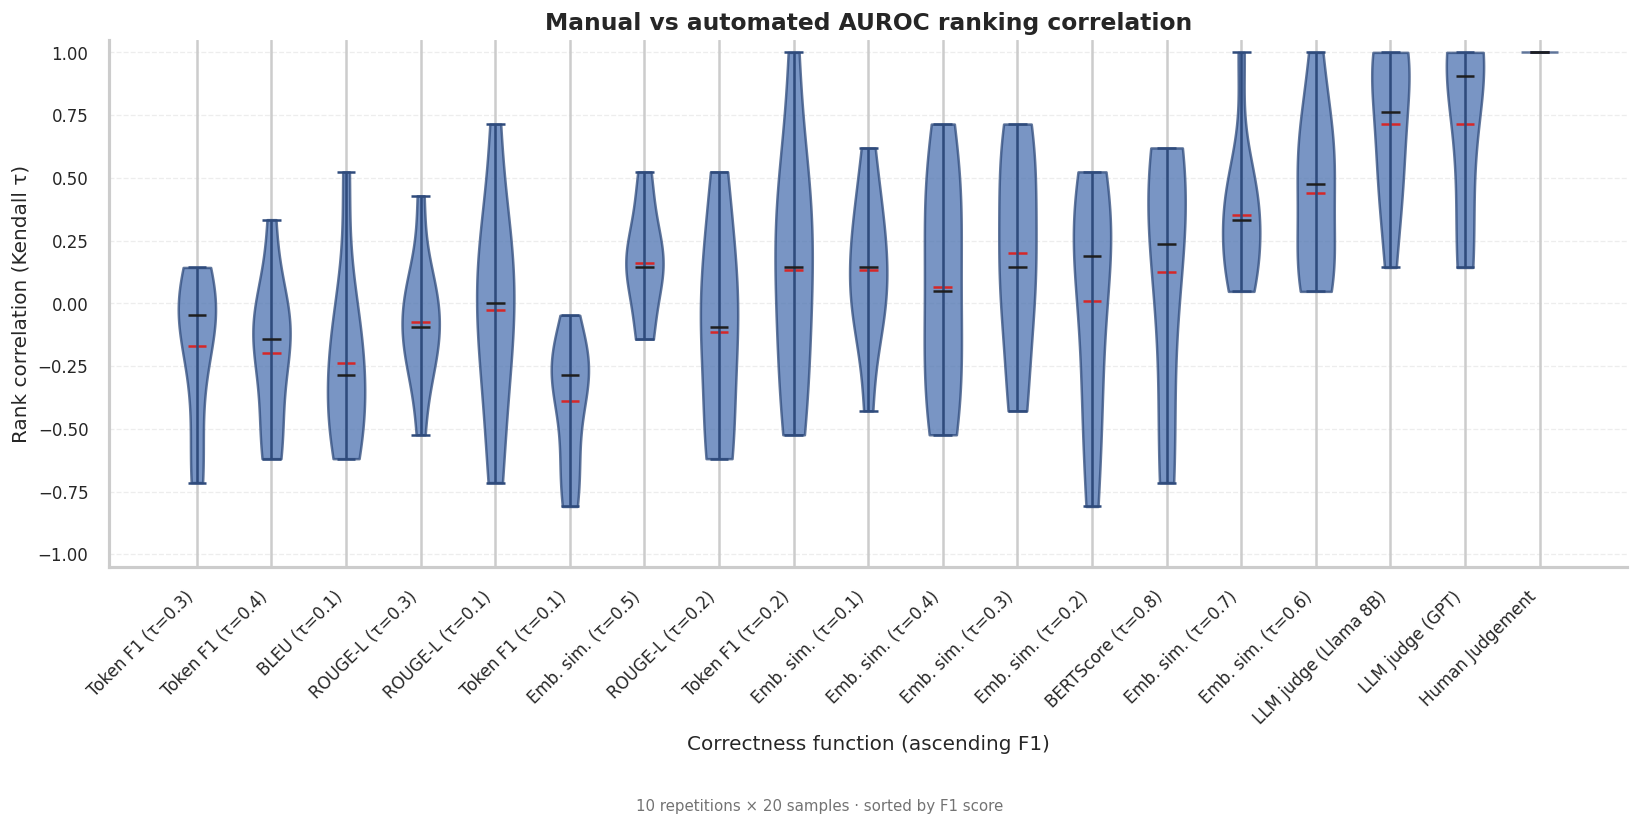

In [ ]:
# Sort by increasing F1 score of correctness function
sorted_correct = sorted([(k, aurocs[k]['metrics']['f1'][0]) for k in aurocs.keys()], key=lambda x: x[1])
labels = [x[0] for x in sorted_correct]
labels = [format_correctness_label(l) for l in labels]
data = [rank_tau[x[0]] for x in sorted_correct]

fig, ax = plt.subplots(figsize=(max(14, 0.55 * len(labels)), 7))
parts = ax.violinplot(data, showmeans=True, showmedians=True)
style_violinplot(parts)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels([wrap_label(l) for l in labels], rotation=45, ha="right")
ax.set_xlabel("Correctness function (ascending F1)")
ax.set_ylabel("Rank correlation (Kendall τ)")
ax.set_title("Manual vs automated AUROC ranking correlation")
ax.set_ylim(-1.05, 1.05)
style_axes(ax)
fig.text(
    0.5,
    0.01,
    f"{reps} repetitions × {size} samples · sorted by F1 score",
    ha="center",
    fontsize=9,
    color="0.45",
)
fig.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(f"/auroc_eval/results/plots/bootstrapping/bootstrapping_rank_corr_{model_name}.pdf")
plt.show()



#### Regarding correctness functions vs the mean and standard deviation of various UQs

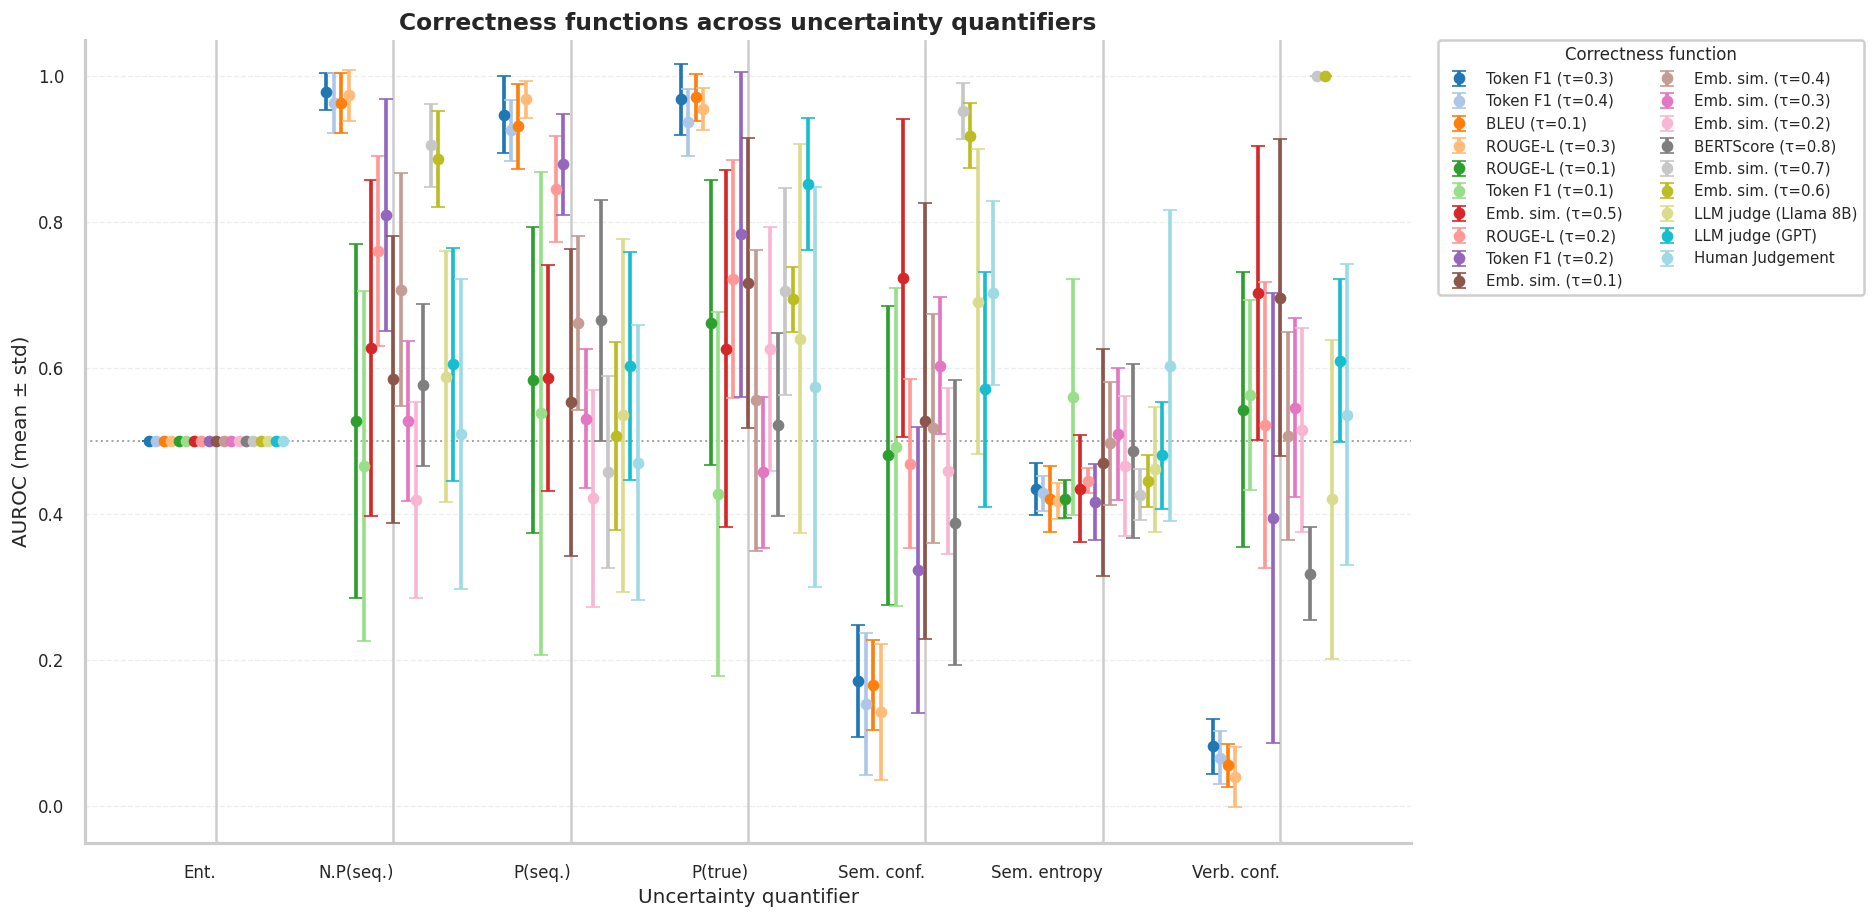

In [807]:
# Opposite view: x-axis = uncertainty quantifiers, series = correctness functions

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_rows = []
for correctness_name, values in aurocs.items():
    unc_metrics = values.get("uncertainty_metrics", {})
    for metric_name, metric_val in unc_metrics.items():
        if metric_name.endswith("_sampled"):
            continue
        if isinstance(metric_val, tuple) and len(metric_val) == 2:
            mean_val, std_val = metric_val
        else:
            mean_val, std_val = float(metric_val), 0.0
        plot_rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": metric_name,
                "auroc_mean": mean_val,
                "auroc_std": std_val,
            }
        )

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError("No aggregated uncertainty metrics found in `aurocs`.")

metric_order = sorted(plot_df["uncertainty_metric"].unique())
available_correctness = list(plot_df["correctness"].unique())

def get_f1_mean(c_name):
    f1_val = aurocs.get(c_name, {}).get("metrics", {}).get("f1", None)
    if isinstance(f1_val, tuple) and len(f1_val) == 2:
        return float(f1_val[0])
    if isinstance(f1_val, (int, float, np.floating)):
        return float(f1_val)
    return np.nan

correctness_order = sorted(
    available_correctness,
    key=lambda c: (np.isnan(get_f1_mean(c)), get_f1_mean(c) if not np.isnan(get_f1_mean(c)) else np.inf),
)

n_groups = len(metric_order)
n_series = len(correctness_order)
x = np.arange(n_groups)
bar_width = 0.8 / max(1, n_series)
colors = plt.cm.tab20(np.linspace(0, 1, n_series))

fig, ax = plt.subplots(figsize=(max(16, 1.0 * n_groups), 8))
for i, (corr_name, color) in enumerate(zip(correctness_order, colors)):
    corr_df = (
        plot_df[plot_df["correctness"] == corr_name]
        .set_index("uncertainty_metric")
        .reindex(metric_order)
        .reset_index()
    )
    offsets = x - 0.4 + (i + 0.5) * bar_width
    ax.bar(offsets, corr_df["auroc_mean"], width=bar_width, facecolor=(0, 0, 0, 0), edgecolor=(0, 0, 0, 0), linewidth=0)
    ax.errorbar(
        offsets,
        corr_df["auroc_mean"],
        yerr=corr_df["auroc_std"],
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=2.2,
        capsize=4,
        markersize=6,
        label=wrap_label(corr_name, max_len=30, type_label="correctness"),
    )

ax.set_xticks(x)
ax.set_xticklabels([wrap_label(m, type_label="uncertainty") for m in metric_order], rotation=0, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Uncertainty quantifier")
ax.set_ylabel("AUROC (mean ± std)")
ax.set_title("Correctness functions across uncertainty quantifiers")
ax.axhline(0.5, color="0.65", linestyle=":", linewidth=1.2, zorder=0)
style_axes(ax)
legend_outside(ax, title="Correctness function", ncol=2 if n_series > 8 else 1)
fig.tight_layout()
plt.show()

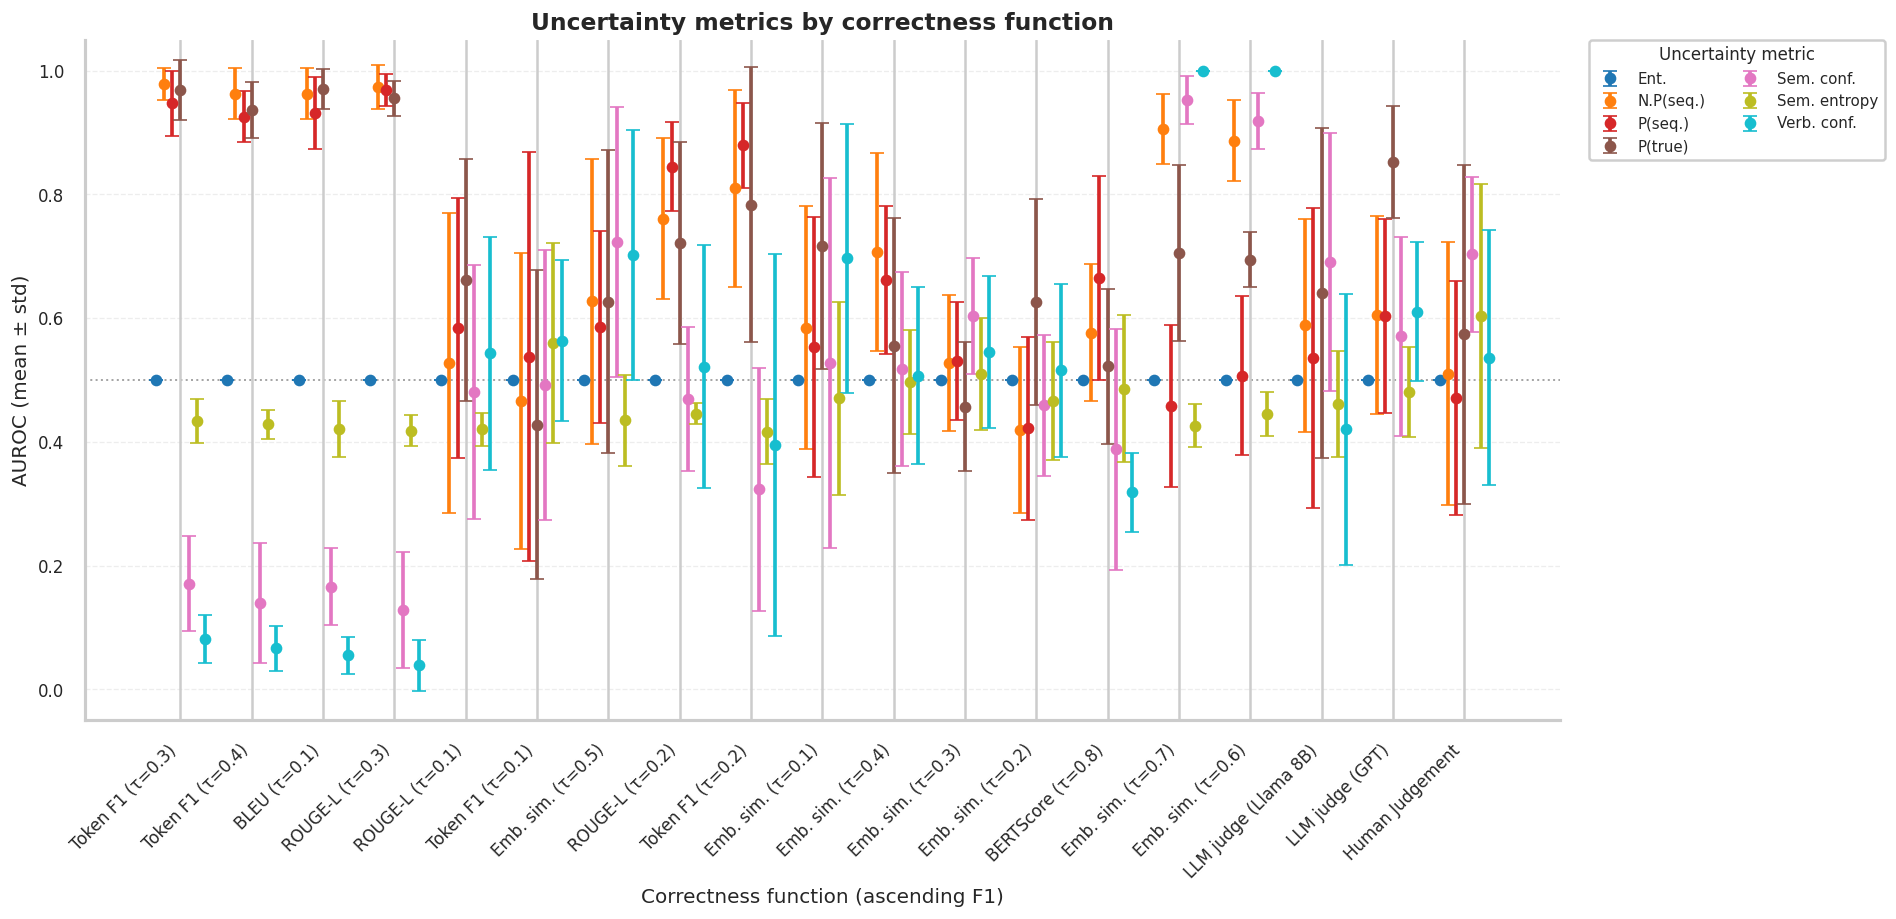

In [808]:
# Side-by-side means with transparent bars + colored spread lines (std)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_rows = []
for correctness_name, values in aurocs.items():
    unc_metrics = values.get("uncertainty_metrics", {})
    for metric_name, metric_val in unc_metrics.items():
        if metric_name.endswith("_sampled"):
            continue
        if isinstance(metric_val, tuple) and len(metric_val) == 2:
            mean_val, std_val = metric_val
        else:
            mean_val, std_val = float(metric_val), 0.0
        plot_rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": metric_name,
                "auroc_mean": mean_val,
                "auroc_std": std_val,
            }
        )

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError("No aggregated uncertainty metrics found in `aurocs`.")

available_correctness = list(plot_df["correctness"].unique())

def get_f1_mean(c_name):
    f1_val = aurocs.get(c_name, {}).get("metrics", {}).get("f1", None)
    if isinstance(f1_val, tuple) and len(f1_val) == 2:
        return float(f1_val[0])
    if isinstance(f1_val, (int, float, np.floating)):
        return float(f1_val)
    return np.nan

correctness_order = sorted(
    available_correctness,
    key=lambda c: (np.isnan(get_f1_mean(c)), get_f1_mean(c) if not np.isnan(get_f1_mean(c)) else np.inf),
)

metric_order = sorted(plot_df["uncertainty_metric"].unique())
n_groups = len(correctness_order)
n_metrics = len(metric_order)
x = np.arange(n_groups)
bar_width = 0.8 / max(1, n_metrics)
colors = plt.cm.tab10(np.linspace(0, 1, n_metrics))

fig, ax = plt.subplots(figsize=(max(14, 0.85 * n_groups), 8))
for i, (metric_name, color) in enumerate(zip(metric_order, colors)):
    metric_df = (
        plot_df[plot_df["uncertainty_metric"] == metric_name]
        .set_index("correctness")
        .reindex(correctness_order)
        .reset_index()
    )
    offsets = x - 0.4 + (i + 0.5) * bar_width
    ax.bar(offsets, metric_df["auroc_mean"], width=bar_width, facecolor=(0, 0, 0, 0), edgecolor=(0, 0, 0, 0), linewidth=0)
    ax.errorbar(
        offsets,
        metric_df["auroc_mean"],
        yerr=metric_df["auroc_std"],
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=2.2,
        capsize=4,
        markersize=6,
        label=wrap_label(metric_name, type_label="uncertainty"),
    )

ax.set_xticks(x)
ax.set_xticklabels([wrap_label(c, type_label="correctness") for c in correctness_order], rotation=45, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Correctness function (ascending F1)")
ax.set_ylabel("AUROC (mean ± std)")
ax.set_title("Uncertainty metrics by correctness function")
ax.axhline(0.5, color="0.65", linestyle=":", linewidth=1.2, zorder=0)
style_axes(ax)
legend_outside(ax, title="Uncertainty metric", ncol=2 if n_metrics > 6 else 1)
fig.tight_layout()
plt.show()

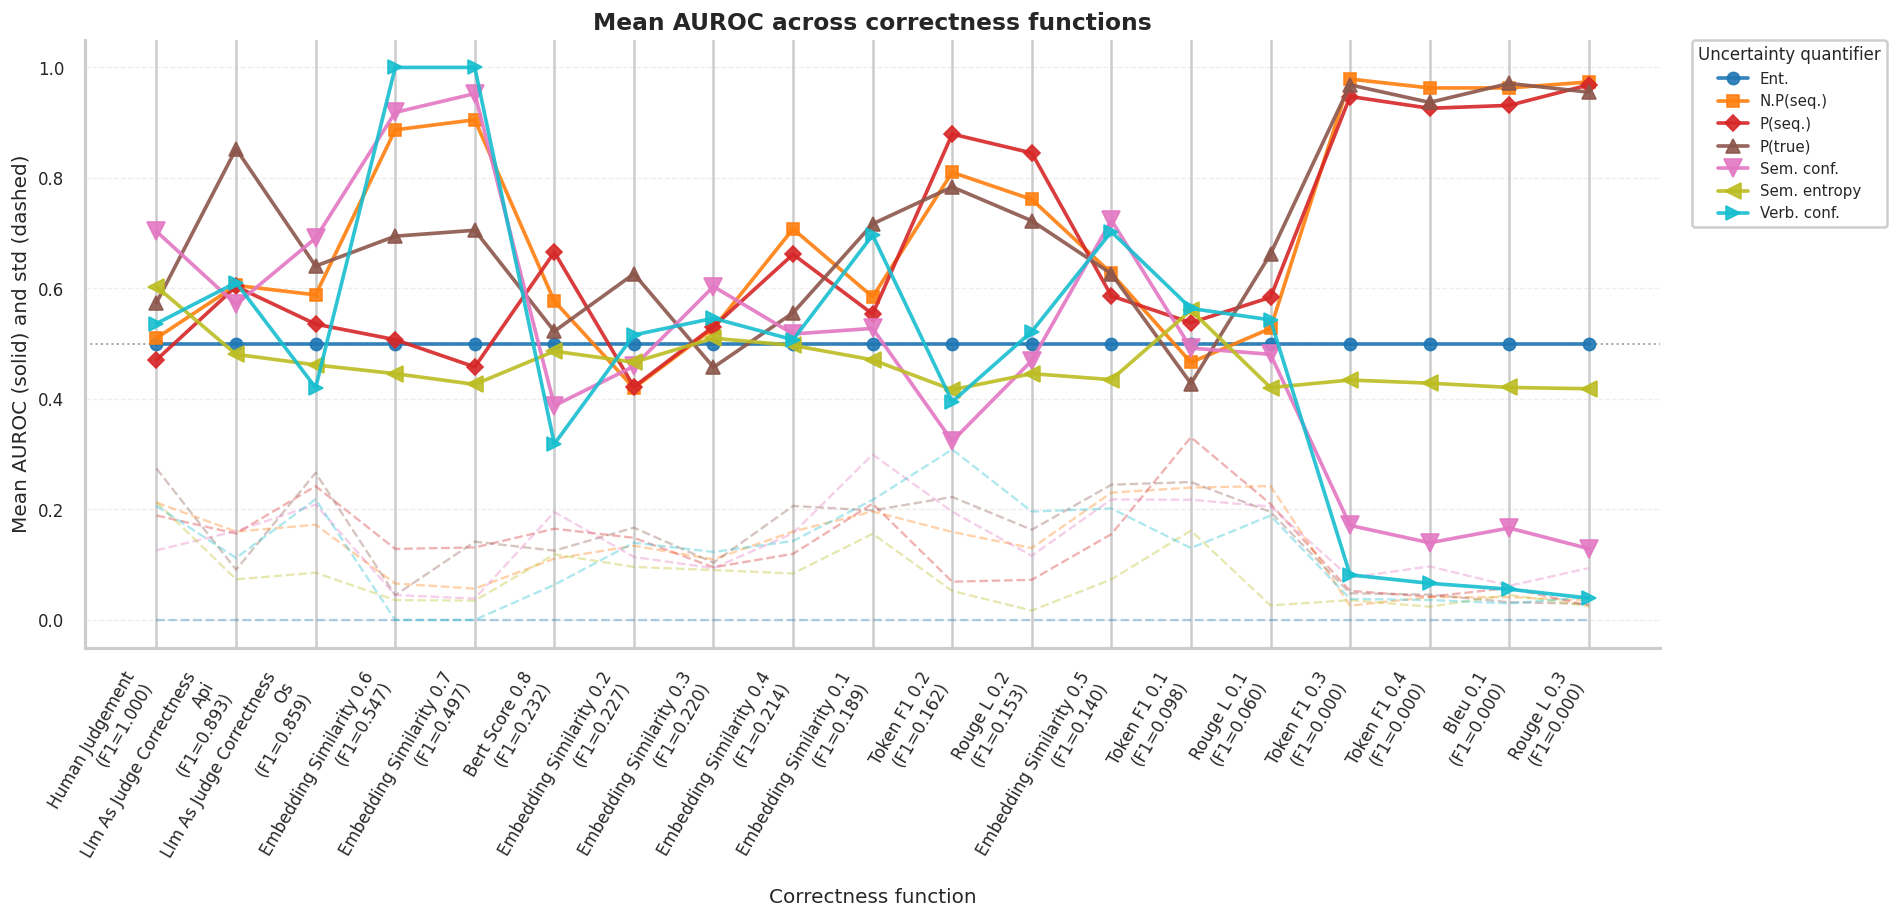

In [809]:
# Line plot of AUROC means across correctness functions

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_rows = []
for correctness_name, values in aurocs.items():
    unc_metrics = values.get("uncertainty_metrics", {})
    for metric_name, metric_val in unc_metrics.items():
        if metric_name.endswith("_sampled"):
            continue
        if isinstance(metric_val, tuple) and len(metric_val) == 2:
            mean_val, std_val = metric_val[0], metric_val[1]
        else:
            mean_val, std_val = float(metric_val), 0.0
        plot_rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": metric_name,
                "auroc_mean": mean_val,
                "auroc_std": std_val,
            }
        )

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError("No aggregated uncertainty metrics found in `aurocs`.")

available_correctness = list(plot_df["correctness"].unique())

def get_f1_mean(c_name):
    f1_val = aurocs.get(c_name, {}).get("metrics", {}).get("f1", None)
    if isinstance(f1_val, tuple) and len(f1_val) == 2:
        return float(f1_val[0])
    if isinstance(f1_val, (int, float, np.floating)):
        return float(f1_val)
    return np.nan

correctness_order = sorted(
    available_correctness,
    key=lambda c: (np.isnan(get_f1_mean(c)), -get_f1_mean(c) if not np.isnan(get_f1_mean(c)) else -np.inf),
)

metric_order = sorted(plot_df["uncertainty_metric"].unique())
hj_unc = aurocs.get("human_judgement", {}).get("uncertainty_metrics", {})
quality_raw = {}
for m in metric_order:
    val = hj_unc.get(m, None)
    if isinstance(val, tuple) and len(val) >= 1:
        quality_raw[m] = float(val[0])
    elif isinstance(val, (int, float, np.floating)):
        quality_raw[m] = float(val)
    else:
        quality_raw[m] = 0.5

q_vals = np.array(list(quality_raw.values()), dtype=float)
q_min, q_max = np.min(q_vals), np.max(q_vals)
if q_max > q_min:
    q_norm = {m: (quality_raw[m] - q_min) / (q_max - q_min) for m in metric_order}
else:
    q_norm = {m: 0.5 for m in metric_order}

min_size, max_size = 45, 110
marker_sizes = {m: min_size + q_norm[m] * (max_size - min_size) for m in metric_order}
marker_cycle = ["o", "s", "D", "^", "v", "<", ">", "X", "P", "*"]
metric_markers = {m: marker_cycle[i % len(marker_cycle)] for i, m in enumerate(metric_order)}

pivot_mean = (
    plot_df.pivot(index="correctness", columns="uncertainty_metric", values="auroc_mean")
    .reindex(correctness_order)
)
pivot_std = (
    plot_df.pivot(index="correctness", columns="uncertainty_metric", values="auroc_std")
    .reindex(correctness_order)
)

x = np.arange(len(correctness_order))
xtick_labels = []
for c in correctness_order:
    f1_mean = get_f1_mean(c)
    f1_text = f"{f1_mean:.3f}" if not np.isnan(f1_mean) else "n/a"
    xtick_labels.append(f"{wrap_label(c)}\n(F1={f1_text})")

colors = plt.cm.tab10(np.linspace(0, 1, len(metric_order)))
fig, ax = plt.subplots(figsize=(max(14, 0.85 * len(correctness_order)), 8))
for color, metric_name in zip(colors, metric_order):
    mean_vals = pivot_mean[metric_name].to_numpy(dtype=float)
    std_vals = pivot_std[metric_name].to_numpy(dtype=float)
    ax.plot(
        x,
        mean_vals,
        marker=metric_markers[metric_name],
        markersize=marker_sizes[metric_name] ** 0.5,
        linewidth=2.2,
        color=color,
        label=wrap_label(metric_name, type_label="uncertainty"),
        alpha=0.9,
    )
    ax.plot(x, std_vals, linestyle="--", linewidth=1.4, color=color, alpha=0.35)

ax.set_xticks(x)
ax.set_xticklabels([format_correctness_label(x) for x in xtick_labels], rotation=60, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Correctness function")
ax.set_ylabel("Mean AUROC (solid) and std (dashed)")
ax.set_title("Mean AUROC across correctness functions")
ax.axhline(0.5, color="0.65", linestyle=":", linewidth=1.2, zorder=0)
style_axes(ax)
legend_outside(ax, title="Uncertainty quantifier", ncol=1 if len(metric_order) > 6 else 1)
fig.tight_layout()
plt.show()

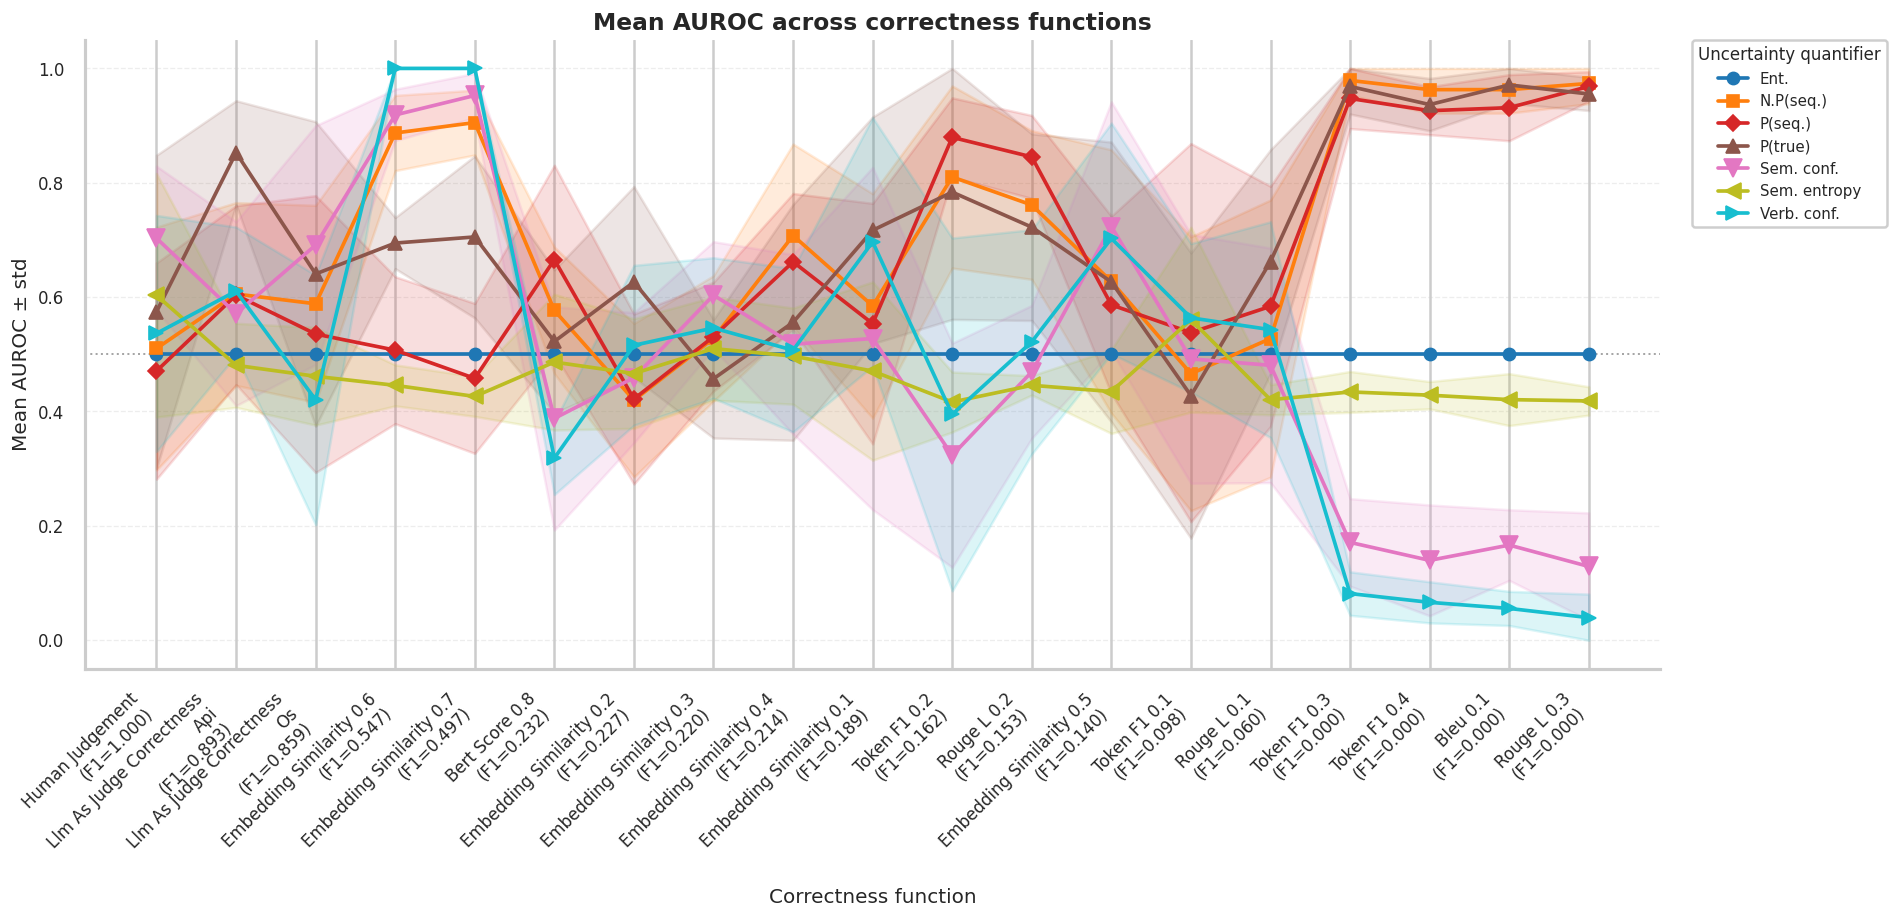

In [ ]:
# Line plot of AUROC means across correctness functions (with std bands and ranking plots)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_rows = []
for correctness_name, values in aurocs.items():
    unc_metrics = values.get("uncertainty_metrics", {})
    for metric_name, metric_val in unc_metrics.items():
        if metric_name.endswith("_sampled"):
            continue
        if isinstance(metric_val, tuple) and len(metric_val) == 2:
            mean_val = float(metric_val[0])
            std_val = float(metric_val[1])
        else:
            mean_val = float(metric_val)
            std_val = 0.0
        plot_rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": metric_name,
                "auroc_mean": mean_val,
                "auroc_std": std_val,
            }
        )

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError("No aggregated uncertainty metrics found in `aurocs`.")

available_correctness = list(plot_df["correctness"].unique())

def get_f1_mean(c_name):
    f1_val = aurocs.get(c_name, {}).get("metrics", {}).get("f1", None)
    if isinstance(f1_val, tuple) and len(f1_val) == 2:
        return float(f1_val[0])
    if isinstance(f1_val, (int, float, np.floating)):
        return float(f1_val)
    return np.nan

correctness_order = sorted(
    available_correctness,
    key=lambda c: (np.isnan(get_f1_mean(c)), -get_f1_mean(c) if not np.isnan(get_f1_mean(c)) else -np.inf),
)

metric_order = sorted(plot_df["uncertainty_metric"].unique())
hj_unc = aurocs.get("human_judgement", {}).get("uncertainty_metrics", {})
quality_raw = {}
for m in metric_order:
    val = hj_unc.get(m, None)
    if isinstance(val, tuple) and len(val) >= 1:
        quality_raw[m] = float(val[0])
    elif isinstance(val, (int, float, np.floating)):
        quality_raw[m] = float(val)
    else:
        quality_raw[m] = 0.5

q_vals = np.array(list(quality_raw.values()), dtype=float)
q_min, q_max = np.min(q_vals), np.max(q_vals)
if q_max > q_min:
    q_norm = {m: (quality_raw[m] - q_min) / (q_max - q_min) for m in metric_order}
else:
    q_norm = {m: 0.5 for m in metric_order}

min_size, max_size = 45, 110
marker_sizes = {m: min_size + q_norm[m] * (max_size - min_size) for m in metric_order}
marker_cycle = ["o", "s", "D", "^", "v", "<", ">", "X", "P", "*"]
metric_markers = {m: marker_cycle[i % len(marker_cycle)] for i, m in enumerate(metric_order)}

pivot_mean_df = (
    plot_df.pivot(index="correctness", columns="uncertainty_metric", values="auroc_mean")
    .reindex(correctness_order)
)
pivot_std_df = (
    plot_df.pivot(index="correctness", columns="uncertainty_metric", values="auroc_std")
    .reindex(correctness_order)
)

x = np.arange(len(correctness_order))
xtick_labels = []
for c in correctness_order:
    f1_mean = get_f1_mean(c)
    f1_text = f"{f1_mean:.3f}" if not np.isnan(f1_mean) else "n/a"
    xtick_labels.append(f"{wrap_label(c)}\n(F1={f1_text})")

colors = plt.cm.tab10(np.linspace(0, 1, len(metric_order)))

fig, ax = plt.subplots(figsize=(max(14, 0.85 * len(correctness_order)), 8))
for color, metric_name in zip(colors, metric_order):
    mean_vals = pivot_mean_df[metric_name].to_numpy(dtype=float)
    std_vals = np.nan_to_num(pivot_std_df[metric_name].to_numpy(dtype=float), nan=0.0)
    lower = np.clip(mean_vals - std_vals, 0.0, 1.0)
    upper = np.clip(mean_vals + std_vals, 0.0, 1.0)
    ax.fill_between(x, lower, upper, color=color, alpha=0.15)
    ax.plot(
        x,
        mean_vals,
        marker=metric_markers[metric_name],
        markersize=marker_sizes[metric_name] ** 0.5,
        linewidth=2.2,
        color=color,
        label=wrap_label(metric_name, type_label="uncertainty"),
    )

ax.set_xticks(x)
ax.set_xticklabels([format_correctness_label(x) for x in xtick_labels], rotation=45, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Correctness function")
ax.set_ylabel("Mean AUROC ± std")
ax.set_title("Mean AUROC across correctness functions")
ax.axhline(0.5, color="0.65", linestyle=":", linewidth=1.2, zorder=0)
style_axes(ax)
legend_outside(ax, title="Uncertainty quantifier", ncol=1 if len(metric_order) > 6 else 1)
fig.tight_layout()

plt.savefig(f"/auroc_eval/results/plots/bootstrapping/bootstrapping_ranking_{model_name}.pdf")
plt.show()


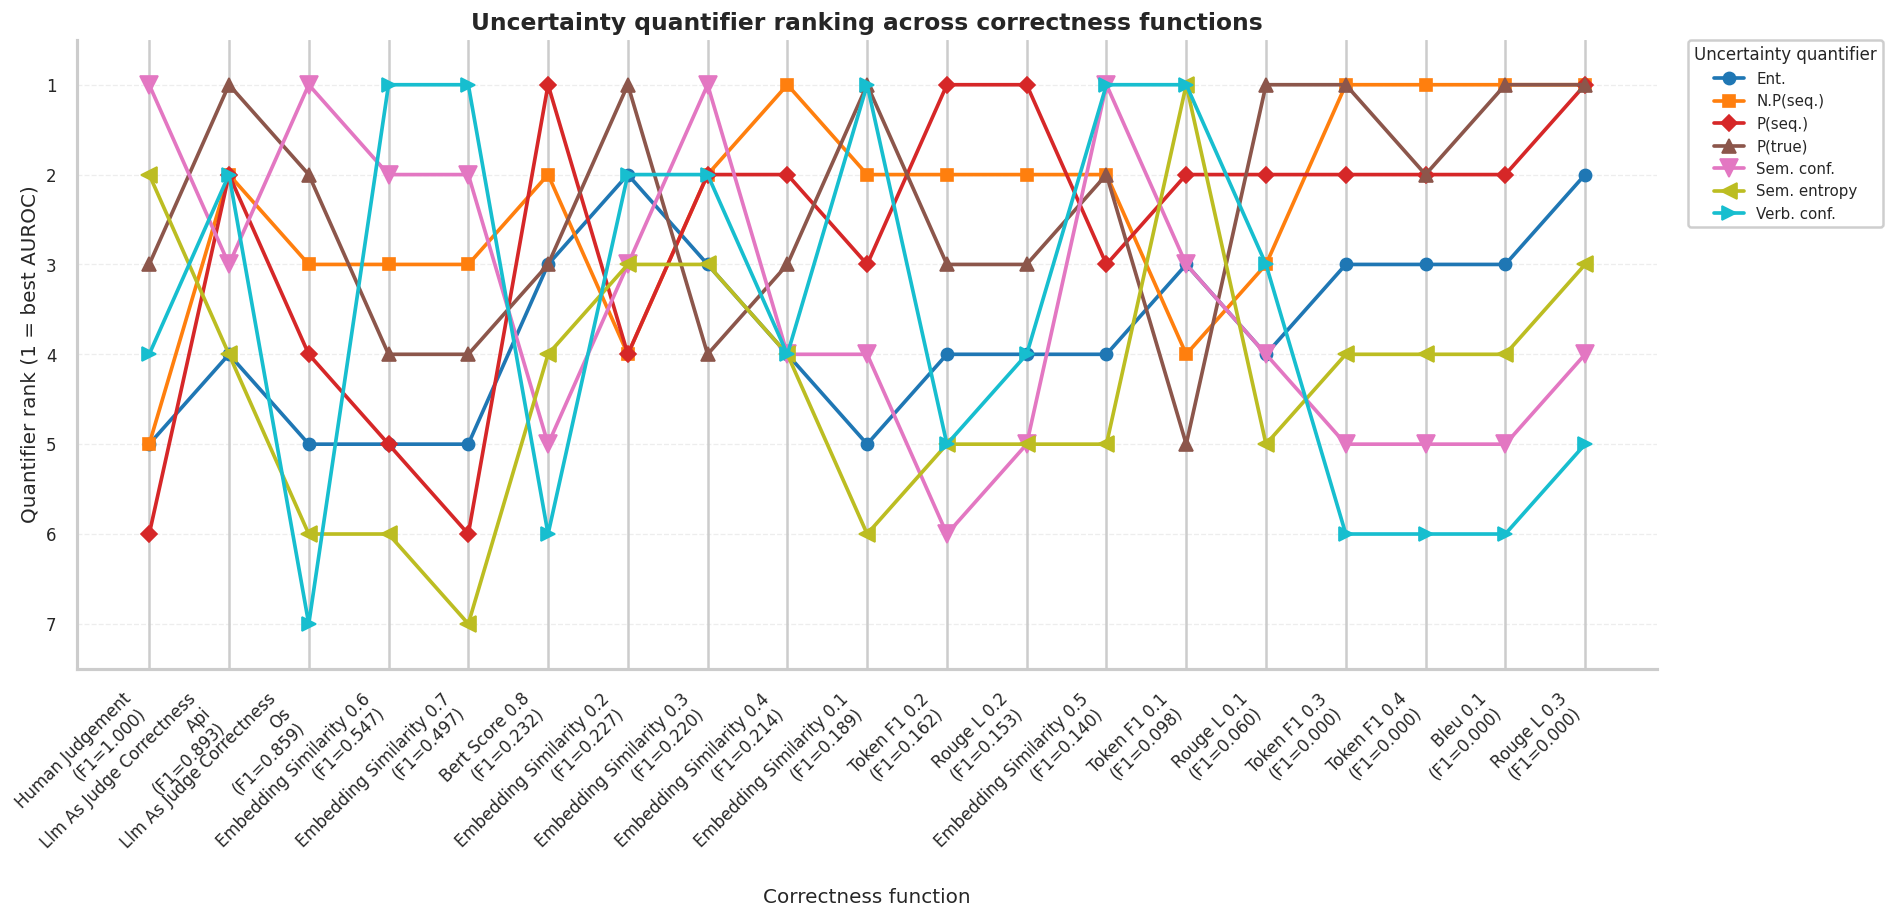

In [ ]:

rank_tolerance = 0.025
rank_rows = {}
for correctness_name in correctness_order:
    row = pivot_mean_df.loc[correctness_name]
    valid = row.dropna().sort_values(ascending=False)
    row_ranks = pd.Series(np.nan, index=metric_order, dtype=float)
    if not valid.empty:
        current_rank = 1
        group_ref = float(valid.iloc[0])
        row_ranks[valid.index[0]] = float(current_rank)
        for metric_name, auroc_val in valid.iloc[1:].items():
            if (group_ref - float(auroc_val)) >= rank_tolerance:
                current_rank += 1
                group_ref = float(auroc_val)
            row_ranks[metric_name] = float(current_rank)
    rank_rows[correctness_name] = row_ranks

rank_df = pd.DataFrame.from_dict(rank_rows, orient="index").reindex(correctness_order)

fig, ax = plt.subplots(figsize=(max(14, 0.85 * len(correctness_order)), 8))
for color, metric_name in zip(colors, metric_order):
    ax.plot(
        x,
        rank_df[metric_name].to_numpy(dtype=float),
        marker=metric_markers[metric_name],
        markersize=marker_sizes[metric_name] ** 0.5,
        linewidth=2.2,
        color=color,
        label=wrap_label(metric_name, type_label="uncertainty"),
    )

ax.set_xticks(x)
ax.set_xticklabels([format_correctness_label(x) for x in xtick_labels], rotation=45, ha="right")
ax.set_yticks(np.arange(1, len(metric_order) + 1, 1))
ax.set_ylim(len(metric_order) + 0.5, 0.5)
ax.set_xlabel("Correctness function")
ax.set_ylabel("Quantifier rank (1 = best AUROC)")
ax.set_title("Uncertainty quantifier ranking across correctness functions")
style_axes(ax)
legend_outside(ax, title="Uncertainty quantifier", ncol=1 if len(metric_order) > 6 else 1)
fig.tight_layout()

plt.savefig(f"/auroc_eval/results/plots/bootstrapping/bootstrapping_auroc_mean_std_{model_name}.pdf")



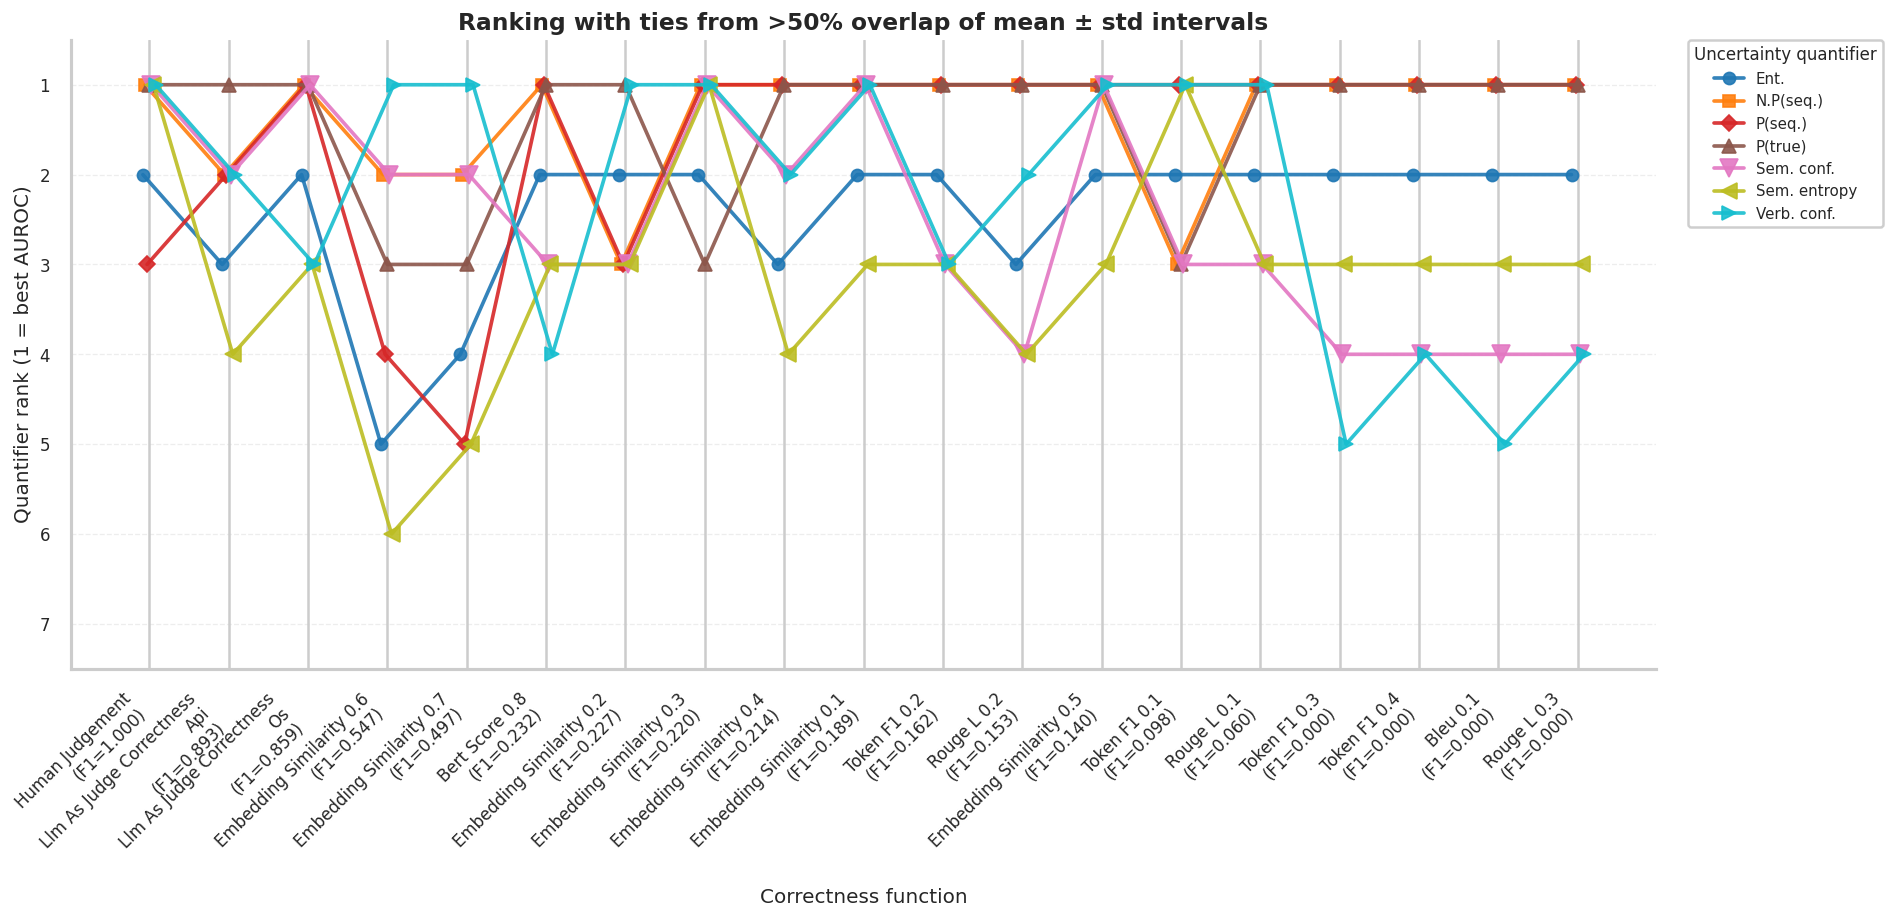

In [812]:

def overlap_ratio(interval_a, interval_b):
    a_low, a_high = interval_a
    b_low, b_high = interval_b
    overlap = max(0.0, min(a_high, b_high) - max(a_low, b_low))
    a_len = max(1e-12, a_high - a_low)
    b_len = max(1e-12, b_high - b_low)
    return overlap / min(a_len, b_len)

rank_rows_overlap = {}
for correctness_name in correctness_order:
    means = pivot_mean_df.loc[correctness_name]
    stds = pivot_std_df.loc[correctness_name].fillna(0.0)
    valid_means = means.dropna().sort_values(ascending=False)
    row_ranks = pd.Series(np.nan, index=metric_order, dtype=float)
    if not valid_means.empty:
        current_rank = 1
        first_metric = valid_means.index[0]
        ref_interval = (
            float(valid_means.loc[first_metric] - stds.loc[first_metric]),
            float(valid_means.loc[first_metric] + stds.loc[first_metric]),
        )
        row_ranks[first_metric] = float(current_rank)
        for metric_name, mean_val in valid_means.iloc[1:].items():
            candidate_interval = (
                float(mean_val - stds.loc[metric_name]),
                float(mean_val + stds.loc[metric_name]),
            )
            if overlap_ratio(ref_interval, candidate_interval) <= 0.5:
                current_rank += 1
                ref_interval = candidate_interval
            row_ranks[metric_name] = float(current_rank)
    rank_rows_overlap[correctness_name] = row_ranks

rank_df_overlap = pd.DataFrame.from_dict(rank_rows_overlap, orient="index").reindex(correctness_order)
jitter_width = 0.08
jitter_offsets = np.linspace(-jitter_width, jitter_width, len(metric_order)) if len(metric_order) > 1 else np.array([0.0])

fig, ax = plt.subplots(figsize=(max(14, 0.85 * len(correctness_order)), 8))
for color, metric_name, jitter in zip(colors, metric_order, jitter_offsets):
    ax.plot(
        x + jitter,
        rank_df_overlap[metric_name].to_numpy(dtype=float),
        marker=metric_markers[metric_name],
        markersize=marker_sizes[metric_name] ** 0.5,
        linewidth=2.2,
        color=color,
        label=wrap_label(metric_name, type_label="uncertainty"),
        alpha=0.9,
    )

ax.set_xticks(x)
ax.set_xticklabels([format_correctness_label(x) for x in xtick_labels], rotation=45, ha="right")
ax.set_yticks(np.arange(1, len(metric_order) + 1, 1))
ax.set_ylim(len(metric_order) + 0.5, 0.5)
ax.set_xlabel("Correctness function")
ax.set_ylabel("Quantifier rank (1 = best AUROC)")
ax.set_title("Ranking with ties from >50% overlap of mean ± std intervals")
style_axes(ax)
legend_outside(ax, title="Uncertainty quantifier", ncol=1 if len(metric_order) > 6 else 1)
fig.tight_layout()
plt.show()

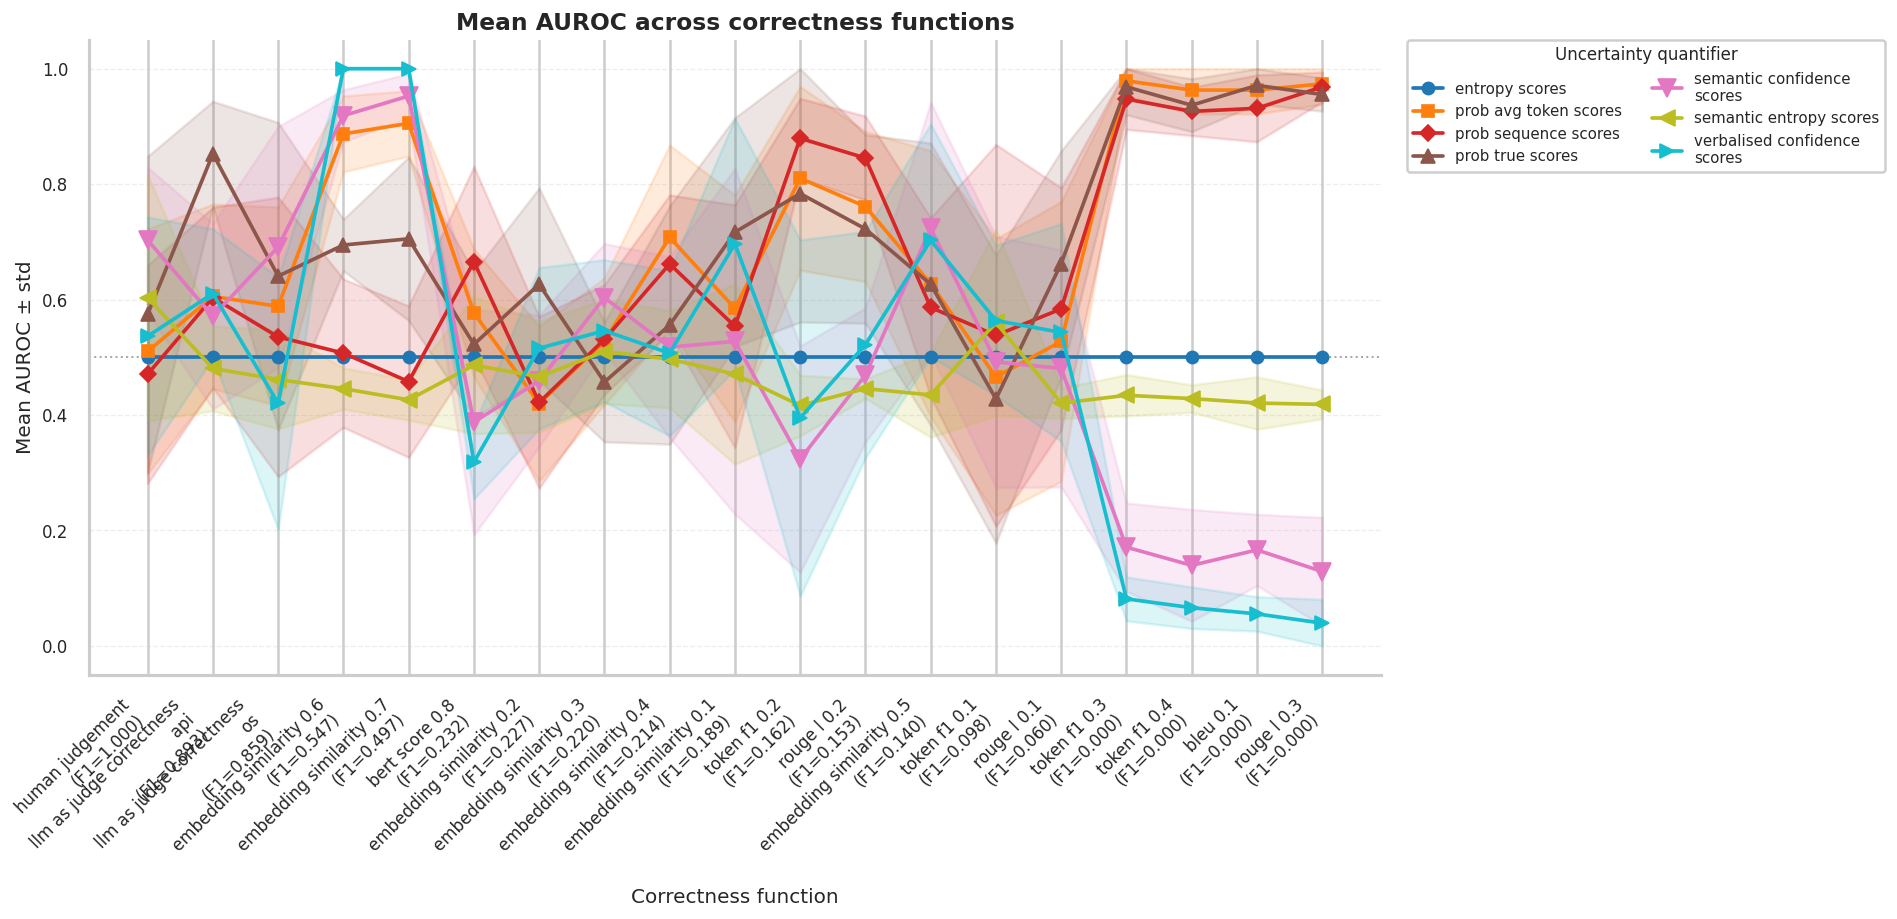

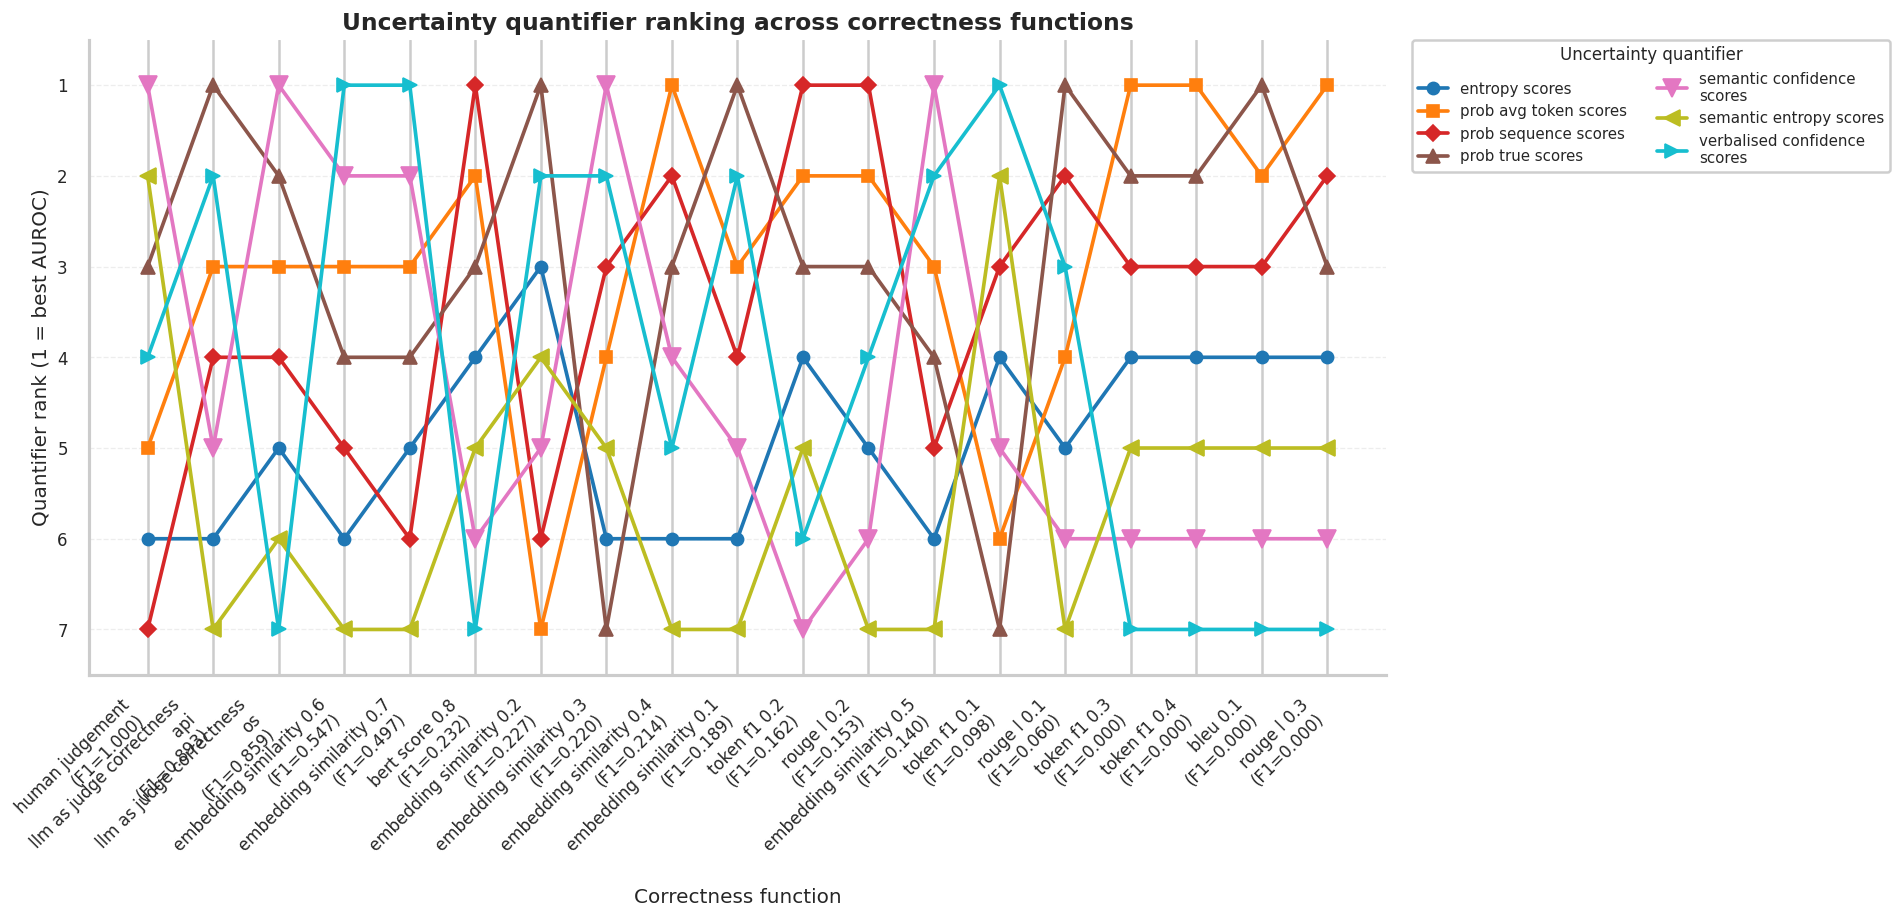

In [813]:
# Line plot of AUROC means and ranking across correctness functions

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_rows = []
for correctness_name, values in aurocs.items():
    unc_metrics = values.get("uncertainty_metrics", {})
    for metric_name, metric_val in unc_metrics.items():
        if metric_name.endswith("_sampled"):
            continue
        if isinstance(metric_val, tuple) and len(metric_val) == 2:
            mean_val = float(metric_val[0])
            std_val = float(metric_val[1])
        else:
            mean_val = float(metric_val)
            std_val = 0.0
        plot_rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": metric_name,
                "auroc_mean": mean_val,
                "auroc_std": std_val,
            }
        )

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError("No aggregated uncertainty metrics found in `aurocs`.")

available_correctness = list(plot_df["correctness"].unique())

def get_f1_mean(c_name):
    f1_val = aurocs.get(c_name, {}).get("metrics", {}).get("f1", None)
    if isinstance(f1_val, tuple) and len(f1_val) == 2:
        return float(f1_val[0])
    if isinstance(f1_val, (int, float, np.floating)):
        return float(f1_val)
    return np.nan

correctness_order = sorted(
    available_correctness,
    key=lambda c: (np.isnan(get_f1_mean(c)), -get_f1_mean(c) if not np.isnan(get_f1_mean(c)) else -np.inf),
)

metric_order = sorted(plot_df["uncertainty_metric"].unique())
hj_unc = aurocs.get("human_judgement", {}).get("uncertainty_metrics", {})
quality_raw = {}
for m in metric_order:
    val = hj_unc.get(m, None)
    if isinstance(val, tuple) and len(val) >= 1:
        quality_raw[m] = float(val[0])
    elif isinstance(val, (int, float, np.floating)):
        quality_raw[m] = float(val)
    else:
        quality_raw[m] = 0.5

q_vals = np.array(list(quality_raw.values()), dtype=float)
q_min, q_max = np.min(q_vals), np.max(q_vals)
if q_max > q_min:
    q_norm = {m: (quality_raw[m] - q_min) / (q_max - q_min) for m in metric_order}
else:
    q_norm = {m: 0.5 for m in metric_order}

min_size, max_size = 45, 110
marker_sizes = {m: min_size + q_norm[m] * (max_size - min_size) for m in metric_order}
marker_cycle = ["o", "s", "D", "^", "v", "<", ">", "X", "P", "*"]
metric_markers = {m: marker_cycle[i % len(marker_cycle)] for i, m in enumerate(metric_order)}

pivot_mean_df = (
    plot_df.pivot(index="correctness", columns="uncertainty_metric", values="auroc_mean")
    .reindex(correctness_order)
)
pivot_std_df = (
    plot_df.pivot(index="correctness", columns="uncertainty_metric", values="auroc_std")
    .reindex(correctness_order)
)

x = np.arange(len(correctness_order))
xtick_labels = []
for c in correctness_order:
    f1_mean = get_f1_mean(c)
    f1_text = f"{f1_mean:.3f}" if not np.isnan(f1_mean) else "n/a"
    xtick_labels.append(f"{wrap_label(c)}\n(F1={f1_text})")

colors = plt.cm.tab10(np.linspace(0, 1, len(metric_order)))

fig, ax = plt.subplots(figsize=(max(14, 0.85 * len(correctness_order)), 8))
for color, metric_name in zip(colors, metric_order):
    mean_vals = pivot_mean_df[metric_name].to_numpy(dtype=float)
    std_vals = np.nan_to_num(pivot_std_df[metric_name].to_numpy(dtype=float), nan=0.0)
    lower = np.clip(mean_vals - std_vals, 0.0, 1.0)
    upper = np.clip(mean_vals + std_vals, 0.0, 1.0)
    ax.fill_between(x, lower, upper, color=color, alpha=0.15)
    ax.plot(
        x,
        mean_vals,
        marker=metric_markers[metric_name],
        markersize=marker_sizes[metric_name] ** 0.5,
        linewidth=2.2,
        color=color,
        label=wrap_label(metric_name),
    )

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=45, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Correctness function")
ax.set_ylabel("Mean AUROC ± std")
ax.set_title("Mean AUROC across correctness functions")
ax.axhline(0.5, color="0.65", linestyle=":", linewidth=1.2, zorder=0)
style_axes(ax)
legend_outside(ax, title="Uncertainty quantifier", ncol=2 if len(metric_order) > 6 else 1)
fig.tight_layout()
plt.show()

rank_df = pivot_mean_df.rank(axis=1, ascending=False, method="min")

fig, ax = plt.subplots(figsize=(max(14, 0.85 * len(correctness_order)), 8))
for color, metric_name in zip(colors, metric_order):
    ax.plot(
        x,
        rank_df[metric_name].to_numpy(dtype=float),
        marker=metric_markers[metric_name],
        markersize=marker_sizes[metric_name] ** 0.5,
        linewidth=2.2,
        color=color,
        label=wrap_label(metric_name),
    )

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=45, ha="right")
ax.set_yticks(np.arange(1, len(metric_order) + 1, 1))
ax.set_ylim(len(metric_order) + 0.5, 0.5)
ax.set_xlabel("Correctness function")
ax.set_ylabel("Quantifier rank (1 = best AUROC)")
ax.set_title("Uncertainty quantifier ranking across correctness functions")
style_axes(ax)
legend_outside(ax, title="Uncertainty quantifier", ncol=2 if len(metric_order) > 6 else 1)
fig.tight_layout()
plt.show()